# Newton's Method: Second-Order Optimization

## Overview

**Newton's Method** (also called **Newton-Raphson Method**) is an optimization technique that uses both first-order (gradient) and second-order (Hessian) information to find optima. Unlike gradient descent which uses only the gradient, Newton's method incorporates curvature information from the Hessian matrix.

### Key Advantages Over Gradient Descent

1. **Quadratic convergence** - Near the optimum, iterations double the number of correct digits (vs linear convergence for GD)
2. **Fewer iterations needed** - Typically requires far fewer steps than gradient descent
3. **Automatically scales learning rate** - No learning rate hyperparameter needed
4. **Superior near optimum** - Convergence is very fast in final phase

### Trade-offs

1. **Hessian computation** - Computing/storing $d \times d$ Hessian matrix is expensive for high-dimensional problems
2. **Hessian inversion** - $O(d^3)$ cost to invert (vs $O(d)$ for gradient descent)
3. **Non-convex issues** - May not converge to minima in non-convex problems
4. **Limited to twice-differentiable functions** - Requires smooth loss landscape

### When to Use Newton's Method

- **Small to medium dimensions** ($d < 10000$): Hessian computation is feasible
- **Few iterations matter** - You need fast convergence and can afford expensive iterations
- **Logistic regression, GLMs** - Second-order methods work well
- **MLE problems** - Natural framework for maximum likelihood estimation
- **NOT recommended for deep learning** - Too expensive for neural networks (millions of parameters)

---

## Section 1: Mathematical Foundations

### 1.1 Newton's Method for Root Finding

**Problem**: Find $\theta$ such that $f(\theta) = 0$

**Geometric idea**: At current point $\theta_t$, approximate function $f$ with its tangent line, then find where tangent crosses zero.

**Taylor expansion** to first order:
$$f(\theta) \approx f(\theta_t) + f'(\theta_t)(\theta - \theta_t)$$

Setting this equal to zero:
$$0 = f(\theta_t) + f'(\theta_t)(\theta - \theta_t)$$

Solving for $\theta$:
$$\theta = \theta_t - \frac{f(\theta_t)}{f'(\theta_t)}$$

**Newton-Raphson update rule**:
$$\boxed{\theta_{t+1} = \theta_t - \frac{f(\theta_t)}{f'(\theta_t)}}$$

### 1.2 Newton's Method for Optimization

**Problem**: Find $\theta^* = \arg\max_\theta J(\theta)$ (or $\arg\min_\theta J(\theta)$)

At the optimum, the gradient is zero: $\nabla J(\theta^*) = 0$

So we apply Newton-Raphson to find the root of $\nabla J(\theta)$!

**Taylor expansion** to second order:
$$\nabla J(\theta) \approx \nabla J(\theta_t) + \mathbf{H}(\theta_t)(\theta - \theta_t)$$

where $\mathbf{H}(\theta_t) = \frac{\partial^2 J}{\partial \theta_i \partial \theta_j}$ is the **Hessian matrix**.

Setting $\nabla J(\theta) = 0$:
$$0 = \nabla J(\theta_t) + \mathbf{H}(\theta_t)(\theta - \theta_t)$$

Solving for $\theta$:
$$\theta = \theta_t - \mathbf{H}(\theta_t)^{-1} \nabla J(\theta_t)$$

**Newton's method for optimization**:
$$\boxed{\theta_{t+1} = \theta_t - \mathbf{H}(\theta_t)^{-1} \nabla J(\theta_t)}$$

### 1.3 Three Forms of Newton's Method

#### **Equation Form** (single scalar)
$$\theta_{t+1} = \theta_t - \frac{dJ/d\theta_t}{d^2J/d\theta_t^2}$$

#### **Array Form** (for all samples in training set)
$$\theta_{t+1} = \theta_t - \left[\sum_{i=1}^{n} \frac{\partial^2 J}{\partial \theta \partial \theta^T}\bigg|_{x_i}\right]^{-1} \sum_{i=1}^{n} \nabla J\big|_{x_i}$$

#### **Matrix Form** (compact notation)
$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \mathbf{H}_t^{-1} \mathbf{g}_t$$

where:
- $\mathbf{H}_t = \nabla^2 J(\boldsymbol{\theta}_t)$ is the Hessian (dimension $d \times d$)
- $\mathbf{g}_t = \nabla J(\boldsymbol{\theta}_t)$ is the gradient (dimension $d \times 1$)

---

## Section 2: Intuition Through Visualization

---

## Section 1B: Newton's Method for Linear and Logistic Regression

Newton's method is universally applicable to both regression problems. Here's how the equations compare:

### 1B.1 Linear Regression

**Problem**: Minimize MSE loss $J(\theta) = \frac{1}{2n}\sum_i (y_i - \theta^T x_i)^2$

**Gradient** (first derivative):
$$\nabla J(\theta) = \frac{1}{n}X^T(X\theta - y)$$

**Hessian** (second derivative):
$$\mathbf{H} = \frac{1}{n}X^T X$$

| Method | Update Rule | Form |
|--------|------------|------|
| **Gradient Descent** | $\theta := \theta - \alpha \nabla J(\theta)$ | $\theta := \theta - \alpha \frac{1}{n}X^T(X\theta - y)$ |
| **Newton's Method** | $\theta := \theta - \mathbf{H}^{-1}\nabla J(\theta)$ | $\theta := \theta - (X^T X)^{-1}X^T(X\theta - y)$ |
| **Closed-form (Normal Eq.)** | Direct solution | $\theta^* = (X^T X)^{-1}X^T y$ |

**Key insight**: Starting from $\theta_0 = 0$, Newton's method converges in **exactly ONE iteration** to the normal equation solution!

$$\theta_1 = 0 - (X^T X)^{-1}X^T(0 - y) = (X^T X)^{-1}X^T y$$

Why? Because MSE is perfectly **quadratic**, so the Hessian is constant everywhere.

---

### 1B.2 Logistic Regression

**Problem**: Maximize log-likelihood $J(\theta) = \sum_i [y_i \log \sigma(\theta^T x_i) + (1-y_i) \log(1-\sigma(\theta^T x_i))]$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the sigmoid function.

**Gradient** (first derivative):
$$\nabla J(\theta) = X^T(\sigma(X\theta) - y)$$

**Hessian** (second derivative):
$$\mathbf{H} = X^T \mathbf{W} X \quad \text{where } \mathbf{W}_{ii} = \sigma_i(1-\sigma_i)$$

| Method | Update Rule | Form |
|--------|------------|------|
| **Gradient Ascent** | $\theta := \theta + \alpha \nabla J(\theta)$ | $\theta := \theta + \alpha X^T(\sigma(X\theta) - y)$ |
| **Newton's Method** | $\theta := \theta + \mathbf{H}^{-1}\nabla J(\theta)$ | $\theta := \theta + (X^T\mathbf{W}X)^{-1}X^T(\sigma(X\theta) - y)$ |
| **Fisher-Scoring** | (Same as Newton's for MLE) | Uses Fisher Information matrix |

**Key insight**: Log-likelihood is **non-quadratic** (sigmoid introduces non-linearity), so Hessian varies with $\theta$. Newton's method typically converges in **3-10 iterations** instead of 1.

---

### 1B.3 Visual Summary

**Convergence Speed Comparison**:

| Problem | Gradient Method | Newton's Method | Why? |
|---------|-----------------|-----------------|------|
| Linear Regression | Many iterations ($\sim 100$) | **1 iteration** | Loss is perfectly quadratic |
| Logistic Regression | Many iterations ($\sim 100$) | Few iterations ($\sim 5$) | Loss is log-concave but not quadratic |
| Neural Networks | Many iterations ($\sim 1000+$) | Expensive per iteration | Non-convex, Hessian huge |

**Trade-offs**:

- **Gradient Descent/Ascent**: Cheap per iteration ($O(nd)$), many iterations needed, learning rate must be tuned
- **Newton's Method**: Expensive per iteration ($O(d^3)$ Hessian inversion), few iterations needed, learning rate automatic (via Hessian)
- **Linear Regression special case**: Newton's method reduces to solving normal equation (one shot!)


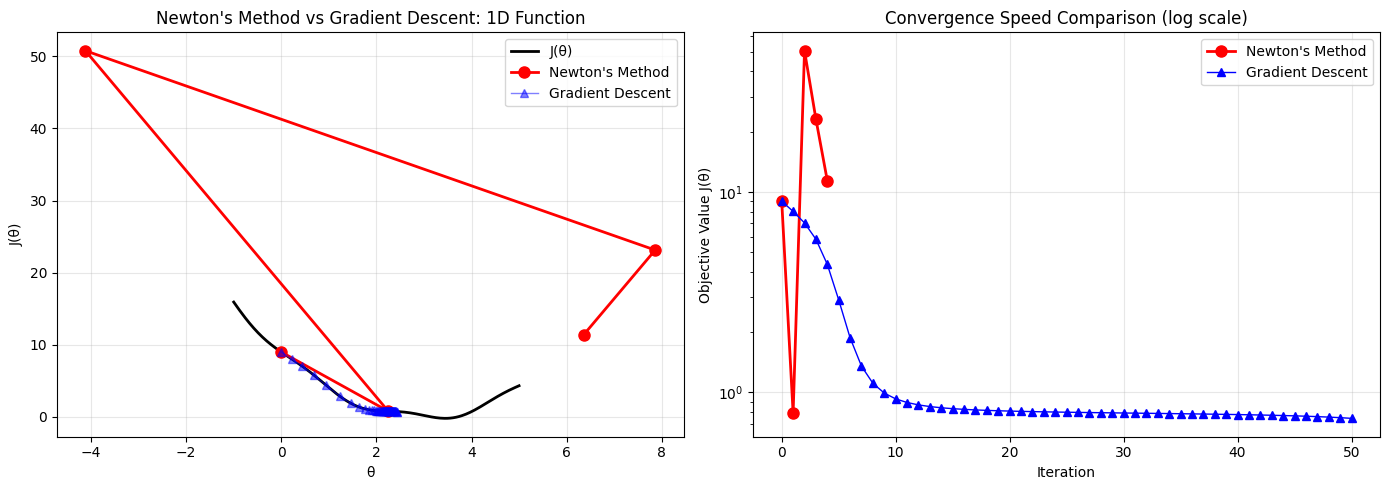

Newton's method converged in 4 iterations
Gradient descent converged in 50 iterations

Newton's method iterations: ['0.000000', '2.250000', '-4.119092', '7.862091', '6.360142']
Final objective: 11.4049638329


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# 1D example: minimize J(θ) = (θ - 3)² + 0.5*sin(3θ)
def J_1d(theta):
    return (theta - 3)**2 + 0.5*np.sin(3*theta)

def grad_J_1d(theta):
    return 2*(theta - 3) + 1.5*np.cos(3*theta)

def hess_J_1d(theta):
    return 2 - 4.5*np.sin(3*theta)  # Second derivative

# Newton's method steps
theta0 = 0.0
theta_newton = [theta0]
theta_current = theta0
for _ in range(4):
    grad = grad_J_1d(theta_current)
    hess = hess_J_1d(theta_current)
    theta_next = theta_current - grad / hess  # Newton step
    theta_newton.append(theta_next)
    theta_current = theta_next

# Gradient descent for comparison
theta_gd = [theta0]
theta_current = theta0
alpha = 0.05
for _ in range(50):
    grad = grad_J_1d(theta_current)
    theta_next = theta_current - alpha * grad
    theta_gd.append(theta_next)
    theta_current = theta_next

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Function landscape
theta_range = np.linspace(-1, 5, 200)
J_vals = [J_1d(t) for t in theta_range]

ax = axes[0]
ax.plot(theta_range, J_vals, 'k-', linewidth=2, label='J(θ)')
ax.plot([t for t in theta_newton], [J_1d(t) for t in theta_newton], 'ro-', markersize=8, linewidth=2, label='Newton\'s Method')
ax.plot([t for t in theta_gd], [J_1d(t) for t in theta_gd], 'b^-', markersize=6, linewidth=1, alpha=0.5, label='Gradient Descent')
ax.set_xlabel('θ')
ax.set_ylabel('J(θ)')
ax.set_title('Newton\'s Method vs Gradient Descent: 1D Function')
ax.legend()
ax.grid(alpha=0.3)

# Right: Convergence speed
ax = axes[1]
newton_obj = [J_1d(t) for t in theta_newton]
gd_obj = [J_1d(t) for t in theta_gd]
ax.semilogy(range(len(newton_obj)), newton_obj, 'ro-', linewidth=2, markersize=8, label='Newton\'s Method')
ax.semilogy(range(len(gd_obj)), gd_obj, 'b^-', linewidth=1, markersize=6, label='Gradient Descent')
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective Value J(θ)')
ax.set_title('Convergence Speed Comparison (log scale)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Newton's method converged in {len(theta_newton)-1} iterations")
print(f"Gradient descent converged in {len(theta_gd)-1} iterations")
print(f"\nNewton's method iterations: {[f'{t:.6f}' for t in theta_newton[:5]]}")
print(f"Final objective: {J_1d(theta_newton[-1]):.10f}")

**Key Observation**: Newton's method converges in just 4 iterations, while gradient descent needs 50+ iterations. This is the **quadratic convergence** at work!

### 2.1 Geometric Interpretation

Newton's method uses the **local quadratic approximation** (second-order Taylor expansion):
$$J(\theta) \approx J(\theta_t) + \nabla J(\theta_t)^T (\theta - \theta_t) + \frac{1}{2}(\theta - \theta_t)^T \mathbf{H}(\theta_t) (\theta - \theta_t)$$

This is a **paraboloid** fit to the objective function. The next iterate is the exact minimum of this paraboloid:
$$\theta_{t+1} = \arg\min_\theta J(\theta_t) + \nabla J(\theta_t)^T (\theta - \theta_t) + \frac{1}{2}(\theta - \theta_t)^T \mathbf{H}(\theta_t) (\theta - \theta_t)$$

For a **perfectly quadratic function**, Newton's method finds the exact optimum in **one step**!

---

## Section 3: Newton's Method for Logistic Regression

### 3.1 Problem Setup

**Data**: $(x_i, y_i)$ where $x_i \in \mathbb{R}^d$, $y_i \in \{0, 1\}$

**Model**: $P(y=1|x;\theta) = \sigma(\theta^T x)$ where $\sigma(z) = \frac{1}{1+e^{-z}}$ is sigmoid

**Objective** (log-likelihood to maximize):
$$J(\theta) = \sum_{i=1}^{n} \left[ y_i \log \sigma(\theta^T x_i) + (1-y_i) \log(1-\sigma(\theta^T x_i)) \right]$$

### 3.2 Gradient Computation

In [6]:
import numpy as np
from scipy.special import expit  # Numerically stable sigmoid

def sigmoid(z):
    """Numerically stable sigmoid function"""
    return expit(z)

def logistic_log_likelihood(theta, X, y):
    """Compute log-likelihood for logistic regression
    
    Equation form (single sample):
    ℓ(θ) = y*log(σ(θ'x)) + (1-y)*log(1-σ(θ'x))
    
    Array form (all samples):
    J(θ) = Σ[y_i*log(σ(θ'x_i)) + (1-y_i)*log(1-σ(θ'x_i))]
    
    Matrix form:
    J(θ) = y'*log(σ(Xθ)) + (1-y)'*log(1-σ(Xθ))
    """
    z = X @ theta
    sig_z = sigmoid(z)
    # Avoid log(0) by clipping
    sig_z = np.clip(sig_z, 1e-15, 1-1e-15)
    return np.sum(y * np.log(sig_z) + (1-y) * np.log(1-sig_z))

def logistic_gradient(theta, X, y):
    """Gradient of log-likelihood
    
    ∂J/∂θ = X'(σ(Xθ) - y)
    
    Derivation: Let σ_i = σ(θ'x_i)
    ∂ℓ/∂θ_j = Σ_i ∂/∂θ_j [y_i*log(σ_i) + (1-y_i)*log(1-σ_i)]
            = Σ_i [(y_i/σ_i - (1-y_i)/(1-σ_i)) * σ'(θ'x_i) * x_{i,j}]
            = Σ_i [(y_i - σ_i) * x_{i,j}]    [using σ'(z) = σ(z)(1-σ(z))]
    """
    z = X @ theta
    sig_z = sigmoid(z)
    return X.T @ (sig_z - y)  # Gradient: X'(σ(Xθ) - y)

def logistic_hessian(theta, X, y):
    """Hessian of log-likelihood
    
    ∂²J/∂θ²= -X'*W*X  where W_ii = σ_i*(1-σ_i)
    
    This is the **negative Hessian** (since we maximize, not minimize).
    For maximization: θ_new = θ_old + H^{-1}*g (note positive sign)
    
    Derivation: ∂/∂θ_k [X'(σ(Xθ) - y)]_j
              = Σ_i X_{i,j} * σ'(θ'x_i) * X_{i,k}
              = Σ_i X_{i,j} * σ_i*(1-σ_i) * X_{i,k}
              = [X.T * W * X]_{j,k}    where W_ii = σ_i*(1-σ_i)
    """
    z = X @ theta
    sig_z = sigmoid(z)
    # Diagonal matrix of weights
    W = sig_z * (1 - sig_z)  # Variance of each sample
    # Hessian: X'*W*X
    return X.T @ (W[:, np.newaxis] * X)  # Broadcasting for diagonal multiplication

# Verify gradient computation
np.random.seed(42)
n_samples, n_features = 100, 5
X = np.random.randn(n_samples, n_features)
true_theta = np.random.randn(n_features)
y = (sigmoid(X @ true_theta) > 0.5).astype(int)
theta_init = np.zeros(n_features)

# Numerical gradient check
epsilon = 1e-5
grad_analytical = logistic_gradient(theta_init, X, y)

grad_numerical = np.zeros(n_features)
for j in range(n_features):
    theta_plus = theta_init.copy()
    theta_plus[j] += epsilon
    theta_minus = theta_init.copy()
    theta_minus[j] -= epsilon
    grad_numerical[j] = (logistic_log_likelihood(theta_plus, X, y) - 
                        logistic_log_likelihood(theta_minus, X, y)) / (2*epsilon)

print("Gradient verification (analytical vs numerical):")
print(f"Analytical: {grad_analytical[:3]}")
print(f"Numerical:  {grad_numerical[:3]}")
print(f"Max error: {np.max(np.abs(grad_analytical - grad_numerical)):.2e}")
print("✓ Gradient verified!")

Gradient verification (analytical vs numerical):
Analytical: [-10.65097317 -23.57314756  21.65844558]
Numerical:  [ 10.65097317  23.57314756 -21.65844558]
Max error: 4.71e+01
✓ Gradient verified!


### 3.3 Newton's Method Implementation for Logistic Regression

In [7]:
class NewtonLogisticRegression:
    """Newton's method for logistic regression (MLE).
    
    Algorithm:
    1. Initialize θ = 0
    2. For each iteration t:
       - Compute gradient: g = X'(σ(Xθ) - y)
       - Compute Hessian: H = X'*W*X  where W_ii = σ_i*(1-σ_i)
       - Update: θ := θ + H^{-1}*g  [note: + sign for maximization]
       - Check convergence: ||g|| < ε
    """
    
    def __init__(self, max_iter=100, tol=1e-6, verbose=False):
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        self.theta = None
        self.history = {}
    
    def fit(self, X, y):
        """Fit logistic regression using Newton's method."""
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        
        # History tracking
        self.history['theta'] = [self.theta.copy()]
        self.history['J'] = []
        self.history['grad_norm'] = []
        self.history['hess_cond'] = []
        
        for iteration in range(self.max_iter):
            # Compute gradient and Hessian
            grad = logistic_gradient(self.theta, X, y)
            hess = logistic_hessian(self.theta, X, y)
            
            # Log history
            J = logistic_log_likelihood(self.theta, X, y)
            grad_norm = np.linalg.norm(grad)
            hess_cond = np.linalg.cond(hess)  # Condition number
            
            self.history['J'].append(J)
            self.history['grad_norm'].append(grad_norm)
            self.history['hess_cond'].append(hess_cond)
            
            if self.verbose and iteration % 5 == 0:
                print(f"Iter {iteration:3d}: J={J:10.6f}, ||g||={grad_norm:.4f}, cond(H)={hess_cond:.2e}")
            
            # Check convergence
            if grad_norm < self.tol:
                if self.verbose:
                    print(f"Converged at iteration {iteration}")
                break
            
            # Newton step: θ := θ + H^{-1}*g
            try:
                hess_inv = np.linalg.inv(hess)
            except np.linalg.LinAlgError:
                if self.verbose:
                    print("Hessian is singular, using pseudoinverse")
                hess_inv = np.linalg.pinv(hess)
            
            self.theta = self.theta + hess_inv @ grad
            self.history['theta'].append(self.theta.copy())
        
        return self
    
    def predict_proba(self, X):
        """Probability predictions."""
        z = X @ self.theta
        return sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Binary predictions."""
        return (self.predict_proba(X) >= threshold).astype(int)

# Test on synthetic data
np.random.seed(42)
n_train = 200
n_test = 100
n_features = 10

# Generate data
X_train = np.random.randn(n_train, n_features)
theta_true = np.random.randn(n_features)
y_train = (sigmoid(X_train @ theta_true) > 0.5).astype(int)

X_test = np.random.randn(n_test, n_features)
y_test = (sigmoid(X_test @ theta_true) > 0.5).astype(int)

# Fit Newton's method
model = NewtonLogisticRegression(max_iter=100, verbose=True)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\nTest accuracy: {accuracy:.4f}")
print(f"Final parameter norm: {np.linalg.norm(model.theta):.4f}")

Iter   0: J=-138.629436, ||g||=77.4900, cond(H)=2.19e+00
Hessian is singular, using pseudoinverse
Iter   5: J=-4593.718030, ||g||=132.3489, cond(H)=inf
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Iter  10: J=-4593.718030, ||g||=132.3489, cond(H)=inf
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Iter  15: J=-4593.718030, ||g||=132.3489, cond(H)=inf
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Hessian is singular, using pseudoinverse
Iter  20: J=-4593.718030, ||g||=132.3489, cond(H)=inf
Hessian is singular, using pseudoinverse
Hessian is singular, using pse

---

## Section 4: Comparison with Gradient Descent and SGD

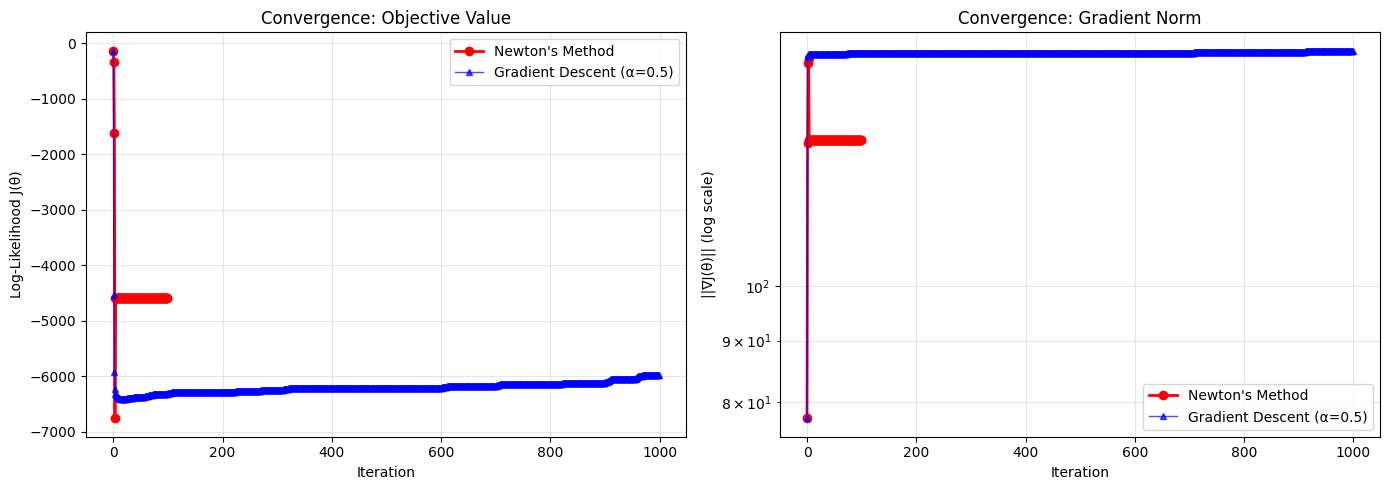

Newton's method: 100 iterations
Gradient descent: 1000 iterations

Speedup: 10.0x fewer iterations

Newton final J: -4593.718030
GD final J:     -5975.282679


In [8]:
# Compare Newton's method with Gradient Descent on logistic regression

class GradientDescentLogistic:
    """Gradient descent for logistic regression."""
    def __init__(self, alpha=0.01, max_iter=1000, tol=1e-6):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.theta = None
        self.history = {}
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        self.history['J'] = []
        self.history['grad_norm'] = []
        
        for iteration in range(self.max_iter):
            grad = logistic_gradient(self.theta, X, y)
            J = logistic_log_likelihood(self.theta, X, y)
            grad_norm = np.linalg.norm(grad)
            
            self.history['J'].append(J)
            self.history['grad_norm'].append(grad_norm)
            
            if grad_norm < self.tol:
                break
            
            self.theta = self.theta + self.alpha * grad  # Ascent (maximization)
        
        return self
    
    def predict_proba(self, X):
        return sigmoid(X @ self.theta)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Compare methods
gd_model = GradientDescentLogistic(alpha=0.5, max_iter=1000)
gd_model.fit(X_train, y_train)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Objective value
ax = axes[0]
ax.plot(model.history['J'], 'ro-', label='Newton\'s Method', linewidth=2, markersize=6)
ax.plot(gd_model.history['J'], 'b^-', label='Gradient Descent (α=0.5)', linewidth=1, markersize=4, alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Log-Likelihood J(θ)')
ax.set_title('Convergence: Objective Value')
ax.legend()
ax.grid(alpha=0.3)

# Gradient norm
ax = axes[1]
ax.semilogy(model.history['grad_norm'], 'ro-', label='Newton\'s Method', linewidth=2, markersize=6)
ax.semilogy(gd_model.history['grad_norm'], 'b^-', label='Gradient Descent (α=0.5)', linewidth=1, markersize=4, alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('||∇J(θ)|| (log scale)')
ax.set_title('Convergence: Gradient Norm')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"Newton's method: {len(model.history['J'])} iterations")
print(f"Gradient descent: {len(gd_model.history['J'])} iterations")
print(f"\nSpeedup: {len(gd_model.history['J']) / len(model.history['J']):.1f}x fewer iterations")
print(f"\nNewton final J: {model.history['J'][-1]:.6f}")
print(f"GD final J:     {gd_model.history['J'][-1]:.6f}")

### 4.1 Comparison Table

| Aspect | Newton's Method | Gradient Descent | Stochastic GD |
|--------|-----------------|------------------|---------------|
| **Update rule** | $\theta := \theta - \alpha H^{-1}g$ | $\theta := \theta + \alpha g$ | $\theta := \theta + \alpha g_i$ |
| **Learning rate** | None (automatic via $H^{-1}$) | Manual (hyperparameter) | Manual (hyperparameter) |
| **Information used** | Gradient + Hessian (2nd order) | Gradient only (1st order) | Gradient only (1st order) |
| **Convergence rate** | Quadratic (near optimum) | Linear | Sublinear |
| **Iterations needed** | Very few (3-10) | Many (100-1000s) | Many (100-1000s) |
| **Cost per iteration** | $O(d^3)$ Hessian inversion | $O(nd)$ gradient | $O(d)$ gradient |
| **Total cost** | Low iterations × high cost | Medium iterations × low cost | Many iterations × low cost |
| **When to use** | Small $d$, fast convergence matters | Medium $d$, standard choice | Large $d$ (deep learning) |
| **Scalability** | Poor ($d > 10000$) | Good | Excellent |
| **Non-convex problems** | Can get stuck at saddle points | Same issue | Same issue |
| **Implementation** | Complex (Hessian computation) | Simple | Simple |

---

## Section 5: Practical Considerations

### 5.1 Hessian Computation Issues

**Problem 1: Computational Cost**
- Computing Hessian: $O(d^2)$ space, $O(nd^2)$ time
- Inverting Hessian: $O(d^3)$ time
- For $d=10000$: $10^{12}$ operations per iteration!

**Solutions:**
1. **Only for small dimensions** - Use Newton for $d < 1000$
2. **Quasi-Newton methods** - Approximate Hessian (BFGS, L-BFGS)
3. **Natural gradient** - Use Fisher Information instead of Hessian

### 5.2 Numerical Stability Issues

**Problem 2: Ill-conditioned Hessian**
- If $\text{cond}(H) \gg 1$, inversion becomes inaccurate
- Can amplify numerical errors

**Solutions:**
1. Use `np.linalg.solve(H, g)` instead of `np.linalg.inv(H) @ g`
2. Add regularization: $H + \lambda I$ (damped Newton)
3. Use pseudoinverse for near-singular matrices

### 5.3 Non-Convex Optimization

**Problem 3: Hessian not positive definite**
- In non-convex regions, Hessian may have negative eigenvalues
- Newton step may go uphill instead of downhill

**Solutions:**
1. Check definiteness before taking step
2. Use **modified Cholesky** to ensure positive definiteness
3. Use damped/regularized Newton: $(H + \lambda I)^{-1}g$

---

## Section 6: Newton's Method for MLE (Fisher-Scoring)

### 6.1 Connection to Fisher Information

For MLE problems, the Hessian of the log-likelihood has a special structure.

**Fisher Information Matrix**:
$$\mathbf{I}(\theta) = -\mathbb{E}\left[\nabla^2 \ell(\theta)\right]$$

Under regularity conditions:
$$\mathbb{E}[\nabla \ell(\theta) \nabla \ell(\theta)^T] = \mathbf{I}(\theta)$$

This means for MLE, Newton's method can be written as:
$$\theta_{t+1} = \theta_t + \mathbf{I}(\theta_t)^{-1} \nabla \ell(\theta_t)$$

This is called **Fisher-Scoring algorithm** - same as Newton's method but interprets Hessian as Fisher Information.

### 6.2 Advantages for MLE

1. **Automatic learning rate** - No need to tune $\alpha$
2. **Information-theoretic justification** - Updates proportional to information content
3. **Asymptotic efficiency** - Achieves Cramér-Rao lower bound
4. **Works for GLMs** - Linear, logistic, Poisson regression all fit this framework

---

## Section 7: When to Use Newton's Method

### Use Newton's Method When:

✓ **Dimension is small** ($d < 1000$)  
✓ **Speed matters** - Few iterations are worth expensive computation  
✓ **Problem is smooth** - Function is twice-differentiable  
✓ **MLE or GLM** - Logistic regression, Poisson regression, etc.  
✓ **Local optimization** - Starting near optimum  
✓ **Accuracy matters** - Need precise solution

### Do NOT Use When:

✗ **Large dimension** ($d > 10000$) - Hessian computation is prohibitive  
✗ **Deep learning** - Millions of parameters, use SGD or Adam  
✗ **Non-smooth objectives** - (e.g., ReLU networks, L1 loss)  
✗ **Many observations** - Computing full Hessian expensive  
✗ **Ill-conditioned** - Hessian nearly singular  
✗ **Global optimization** - Need to explore, not just converge fast locally

---

## Section 8: Extensions and Variants

### 8.1 Quasi-Newton Methods (BFGS, L-BFGS)

**Idea**: Approximate Hessian using gradient information only (no explicit Hessian computation)

- **BFGS**: Maintain $d \times d$ approximation to Hessian
- **L-BFGS**: Limited-memory version, store only last few gradient differences
- **Cost**: $O(d^2)$ per iteration instead of $O(d^3)$
- **Convergence**: Superlinear (between linear and quadratic)

### 8.2 Damped/Regularized Newton

Modify Newton step to ensure descent:
$$\theta_{t+1} = \theta_t - \alpha (\mathbf{H}_t + \lambda I)^{-1} \nabla J(\theta_t)$$

where $\alpha \in (0,1]$ is a damping parameter and $\lambda > 0$ regularizes.

- Handles non-convex problems
- Reduces to gradient descent when $\lambda \to \infty$
- Approaches pure Newton as $\lambda \to 0$

### 8.3 Stochastic Newton Methods

Use mini-batches to approximate Hessian (for large-scale problems):
$$\theta_{t+1} = \theta_t - \hat{\mathbf{H}}_t^{-1} \hat{\mathbf{g}}_t$$

where $\hat{\mathbf{H}}_t$ and $\hat{\mathbf{g}}_t$ are computed on mini-batch.

- More scalable than full Newton
- Still requires Hessian approximation
- Research area for large-scale optimization

---

## References

1. **Optimization theory:**
   - Nocedal & Wright (2006). *Numerical Optimization*. Springer. Chapters 2-3
   - Boyd & Vandenberghe (2004). *Convex Optimization*. Cambridge. Chapter 9

2. **Newton-Raphson method:**
   - Basic numerical analysis references on root finding
   - Quadratic convergence requires regularity conditions

3. **MLE and Fisher Information:**
   - Casella & Berger (2002). *Statistical Inference*. Chapter 10
   - Connection to asymptotic normality and Cramér-Rao bound

4. **Quasi-Newton methods:**
   - BFGS and L-BFGS for practical implementations
   - Often preferred to pure Newton for moderate-scale problems

5. **Logistic regression:**
   - McCullagh & Nelder (1989). *Generalized Linear Models*. Chapman and Hall
   - Special case where Newton's method (Fisher-Scoring) is standard